# Abrikosov-pseudofermion (Read-Newns) mean field for the Kondo lattice

`KondoLatticeHamiltonian` (`pyqula.kondolattice`) implements the Read-Newns large-$N$ mean-field
theory of the Kondo lattice / periodic Anderson model (P. Coleman, arXiv:cond-mat/0612006, Sec.
III.C): a conduction-electron Hamiltonian is fused with a second sublattice of localized moments,
each represented by an Abrikosov pseudofermion $\vec S_j=\tfrac12 f_j^\dagger\vec\sigma f_j$ under
the constraint $f_j^\dagger f_j=1$. The exchange coupling $J$ is Hubbard-Stratonovich-decoupled into
a self-consistent hybridization field $V_j=-\tfrac{J}{2}\langle f_j^\dagger c_j\rangle$ (a
"composite fermion") plus a Lagrange multiplier $\lambda_j$ enforcing the local constraint. $V=0$ is
always itself a self-consistent solution, so a nonzero seed is needed to find the genuinely
hybridized (lower-energy) state, which opens a direct hybridization gap $2|V|$.

Converged <n_f> per localized site (target 1.0): [0.99999945]
Converged hybridization V: [0.37376044+0.j]
Direct hybridization gap 2|V|: 0.747520876897618


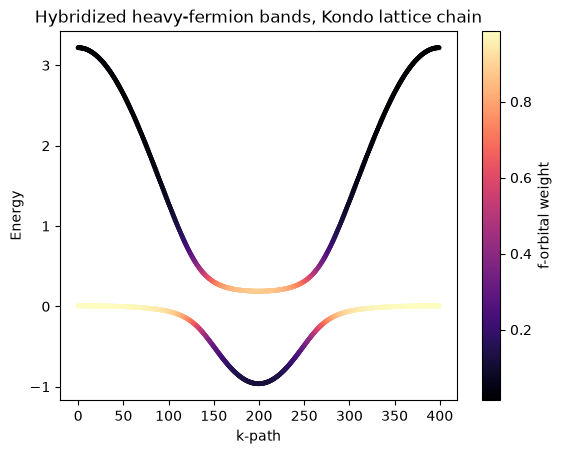

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.kondolattice import KondoLatticeHamiltonian

gc = geometry.chain()
hc = gc.get_hamiltonian(has_spin=True) # conduction electrons
h = KondoLatticeHamiltonian(hc)

seed = ([0.3+0.0j],[0.0]) # (V,lam) initial guess -- needed to escape the trivial V=0 solution
h2 = h.get_mean_field_hamiltonian(J=1.5,filling=0.15,nk=150,mf=seed,mix=0.3,
                                   maxerror=1e-6,maxite=3000)

print("Converged <n_f> per localized site (target 1.0):",h2.local_occupation)
print("Converged hybridization V:",h2.hybridization)
print("Direct hybridization gap 2|V|:",2*abs(h2.hybridization[0]))

# f-sublattice sits at z=+1.0: project onto it to see the "heavy" (mostly f) band
(k,e,c) = h2.get_bands(operator=lambda r: 1.*(r[2]>0.5))

plt.scatter(k,e,c=c,cmap="magma",s=6)
plt.colorbar(label="f-orbital weight")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Hybridized heavy-fermion bands, Kondo lattice chain")
plt.show()